# Exploring SPY Options Data

**Scope**: end-of-day SPY option-chain snapshots for **Aug 1-5, 2022**: **22,962 rows** across 36 expiries, with quotes, size, volume, greeks, and implied volatility.

**Overview**: activity is short-dated and put-heavy, Friday ATM IV finished below Monday across most comparable expiries, and three of four observable nearest-expiry moves ended inside their straddle break-evens.

### Key findings

1. **Cleaning changes what is usable**: numeric text, composite quote sizes, structural IV gaps, and two quote-less rows require explicit treatment; blank daily volume is treated as zero only for aggregation.
2. **Activity is short-dated and put-heavy**: **41%** of weekly volume expires within one day, roughly two-thirds within a week, and daily put/call volume ratios range from **1.24 to 1.48**.
3. **Volatility ended the week lower**: Friday ATM IV was below Monday at 28 of 30 common expiries, while downside skew rose from about **+1 vol point** at one week to **+9 points** at ten months.
4. **Friday's move finished inside its priced range**: Thursday's 414-strike straddle implied break-evens of **-0.88% / +0.78%**; SPY closed Friday **-0.18%**, leaving an expiration payoff equal to **16%** of the premium.

## 0 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -- fixed palette and assignment order --
INK, SEC, MUT = "#0b0b0b", "#52514e", "#898781"          # text tokens
GRID, AXIS, SURF = "#e1e0d9", "#c3c2b7", "#fcfcfb"        # chrome
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
CAT = [BLUE, ORANGE, AQUA, YELLOW]                        # categorical slots 1-4
SEQ = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # ordered: Mon -> Fri
LIGHT_BLUE = "#b7d3f6"

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "figure.dpi": 110, "font.size": 10, "text.color": INK,
    "axes.labelcolor": SEC, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUT, "ytick.color": MUT, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7, "axes.axisbelow": True,
    "legend.frameon": False, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
})

def tidy(ax, xgrid=False):
    """Recessive chrome: horizontal gridlines only, unless xgrid is requested."""
    ax.xaxis.grid(xgrid)

pd.set_option("display.width", 140)

## 1 · Data cleaning

The raw file requires explicit normalization before analysis.

| # | Issue | Evidence | Treatment |
|---|-------|----------|-----------|
| 1 | Headers wrapped as `" [NAME]"` | all 29 columns | strip padding and brackets |
| 2 | Text cells are left-padded | all object columns | strip before parsing |
| 3 | Numeric fields read as text | blank cells force `object` dtype | coerce with `to_numeric` |
| 4 | Quote size is composite text | `"11 x 1"` | split into bid/ask depth |
| 5 | Blank daily volume | 7,395 call / 7,110 put cells | treat as 0 for aggregation |
| 6 | Blank IV | 100% deep ITM | leave missing as structural |
| 7 | Implausible IV | <=1% or >200% on far wings | mask with an operational sanity screen |
| 8 | Missing call quotes | Aug 3, Sep-06, K=275/300 | drop |

`DTE = 0` rows are retained for volume analysis. The IV screen overwhelmingly hits dead or deep-ITM quotes: of 1,782 flagged values, 62 are out of the money, and only four enter the live OTM, positive-DTE sample used for smile and skew analysis.


In [2]:
opt = pd.read_csv("spy_options_data.csv")
n_raw = len(opt)

# 1-2) strip " [ ]" from headers, and left-padding from every text cell
opt.columns = opt.columns.str.strip().str.strip("[]")
for c in opt.select_dtypes("object").columns:
    opt[c] = opt[c].str.strip()

# 3) numeric columns that arrived as text (blank cells force object dtype)
for c in ["C_IV", "C_VOLUME", "C_LAST", "C_BID", "C_ASK", "P_IV", "P_VOLUME"]:
    opt[c] = pd.to_numeric(opt[c], errors="coerce")

# 4) parse dates; one 16:00 snapshot per day, so the date identifies the snapshot
opt["QUOTE_DATE"] = pd.to_datetime(opt["QUOTE_READTIME"]).dt.normalize()
opt["EXPIRE_DATE"] = pd.to_datetime(opt["EXPIRE_DATE"])

# 5) '11 x 1' quote sizes -> numeric bid/ask depth
for side in ["C", "P"]:
    sz = opt[side + "_SIZE"].str.split(" x ", expand=True).astype(float)
    opt[side + "_BID_SIZE"], opt[side + "_ASK_SIZE"] = sz[0], sz[1]

# 6) treat blank daily volume as zero for aggregation
n_blank_vol = int(opt["C_VOLUME"].isna().sum() + opt["P_VOLUME"].isna().sum())
opt[["C_VOLUME", "P_VOLUME"]] = opt[["C_VOLUME", "P_VOLUME"]].fillna(0)

# sanity check for the markdown claim above: blank IVs are structurally deep-ITM
itm_c = (opt.loc[opt["C_IV"].isna(), "STRIKE"] < opt.loc[opt["C_IV"].isna(), "UNDERLYING_LAST"]).mean()
itm_p = (opt.loc[opt["P_IV"].isna(), "STRIKE"] > opt.loc[opt["P_IV"].isna(), "UNDERLYING_LAST"]).mean()

# 7) operational sanity screen for implausible far-wing IV fits
n_junk = n_junk_otm = n_junk_live_otm = 0
for side in ["C", "P"]:
    c = side + "_IV"
    junk = (opt[c] <= 0.01) | (opt[c] > 2.0)
    otm = opt["STRIKE"] > opt["UNDERLYING_LAST"] if side == "C" else opt["STRIKE"] < opt["UNDERLYING_LAST"]
    live_otm = otm & (opt[side + "_BID"] > 0) & (opt["DTE"] > 0)
    n_junk += int(junk.sum())
    n_junk_otm += int((junk & otm).sum())
    n_junk_live_otm += int((junk & live_otm).sum())
    opt.loc[junk, c] = np.nan

# 8) two rows with no call quote at all
broken = opt["C_BID"].isna() | opt["C_ASK"].isna()
opt = opt[~broken].copy()

# 9) derived fields used throughout
opt["C_MID"] = (opt["C_BID"] + opt["C_ASK"]) / 2
opt["P_MID"] = (opt["P_BID"] + opt["P_ASK"]) / 2
opt["T_YEARS"] = opt["DTE"] / 365.0
opt["MONEYNESS"] = opt["STRIKE"] / opt["UNDERLYING_LAST"]

print(f"rows: {n_raw:,} -> {len(opt):,}  (dropped {int(broken.sum())} broken rows)")
print(f"blank volume cells treated as 0: {n_blank_vol:,}")
print(f"share of blank call IVs that are ITM: {itm_c:.0%}   puts: {itm_p:.0%}")
print(f"IV values masked: {n_junk} ({n_junk_otm} OTM; {n_junk_live_otm} live OTM with DTE > 0)")
print(f"days: {opt['QUOTE_DATE'].nunique()}, expiries: {opt['EXPIRE_DATE'].nunique()}, "
      f"strikes {opt['STRIKE'].min():.0f}-{opt['STRIKE'].max():.0f}, max DTE {opt['DTE'].max():.0f}")

rows: 22,962 -> 22,960  (dropped 2 broken rows)
blank volume cells treated as 0: 14,505
share of blank call IVs that are ITM: 100%   puts: 100%
IV values masked: 1782 (62 OTM; 4 live OTM with DTE > 0)
days: 5, expiries: 36, strikes 85-720, max DTE 872


## 2 · Market overview

SPY fell Tuesday, rallied Wednesday, then traded nearly flat through Friday's close. Put volume exceeded call volume every day; unsigned volume does not identify trade direction or motive.


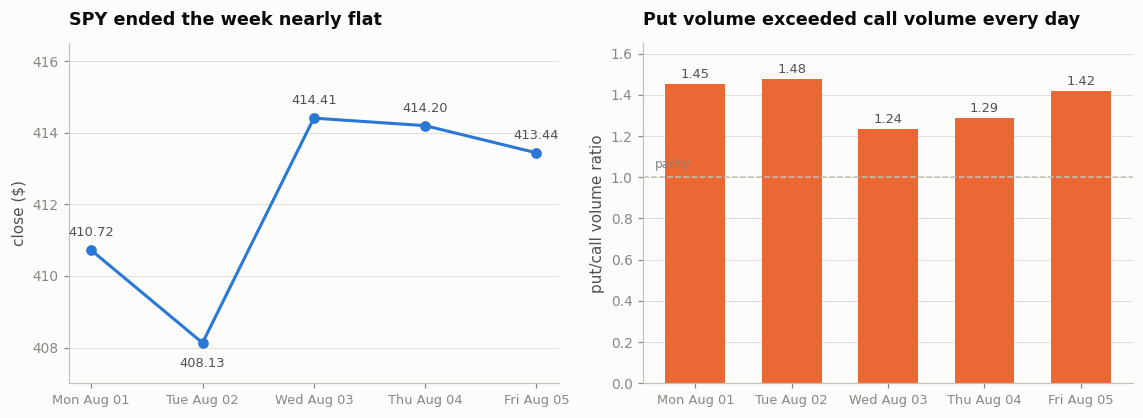

,spy_close,contracts,call_vol,put_vol,close_chg_pct,put_call_ratio
QUOTE_DATE,,,,,,
Mon Aug 01,410.72,4618,704179.0,1023278.0,NaN,1.45
Tue Aug 02,408.13,4532,503212.0,743301.0,-0.63,1.48
Wed Aug 03,414.41,4576,912039.0,1126682.0,1.54,1.24
Thu Aug 04,414.20,4568,443377.0,570084.0,-0.05,1.29
Fri Aug 05,413.44,4666,829797.0,1175551.0,-0.18,1.42


In [3]:
week = (opt.groupby("QUOTE_DATE")
            .agg(spy_close=("UNDERLYING_LAST", "first"),
                 contracts=("STRIKE", "size"),
                 call_vol=("C_VOLUME", "sum"),
                 put_vol=("P_VOLUME", "sum")))
week["close_chg_pct"] = week["spy_close"].pct_change() * 100
week["put_call_ratio"] = week["put_vol"] / week["call_vol"]
week.index = week.index.strftime("%a %b %d")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.9))
x = np.arange(len(week))

ax1.plot(x, week["spy_close"], color=BLUE, lw=2, marker="o", ms=6)
for i, v in enumerate(week["spy_close"]):
    dy = -16 if v == week["spy_close"].min() else 9
    ax1.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(0, dy),
                 ha="center", fontsize=8.5, color=SEC)
ax1.set_title("SPY ended the week nearly flat")
ax1.set_ylabel("close ($)")
ax1.set_ylim(407, 416.5)
ax1.set_xticks(x); ax1.set_xticklabels(week.index, fontsize=8.5)
tidy(ax1)

ax2.bar(x, week["put_call_ratio"], width=0.62, color=ORANGE)
for i, v in enumerate(week["put_call_ratio"]):
    ax2.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(0, 4),
                 ha="center", fontsize=8.5, color=SEC)
ax2.set_title("Put volume exceeded call volume every day")
ax2.set_ylabel("put/call volume ratio")
ax2.axhline(1, color=AXIS, lw=1, ls="--")
ax2.annotate("parity", (-0.42, 1.03), fontsize=8, color=MUT, va="bottom")
ax2.set_ylim(0, 1.65)
ax2.set_xticks(x); ax2.set_xticklabels(week.index, fontsize=8.5)
tidy(ax2)
fig.tight_layout(); plt.show()

week.round(2)

## 3 · Volume concentration

Contracts expiring within one day represent **41%** of weekly volume, and roughly two-thirds expires within a week. The moneyness panel covers ±12% around spot, capturing **93%** of total volume; put activity extends farther into downside strikes than call activity into upside strikes.


volume within ±12% of spot: 93% of week total


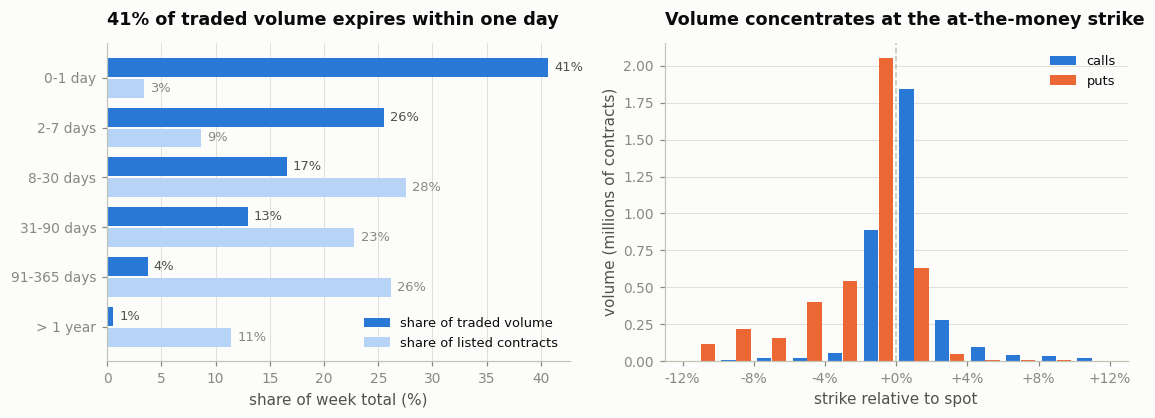

In [4]:
buckets = pd.cut(opt["DTE"], [-0.1, 1, 7, 30, 90, 365, 900],
                 labels=["0-1 day", "2-7 days", "8-30 days", "31-90 days", "91-365 days", "> 1 year"])
grp = opt.groupby(buckets, observed=False)
by_dte = (grp["C_VOLUME"].sum() + grp["P_VOLUME"].sum())
share = by_dte / by_dte.sum() * 100
listed = grp.size() / len(opt) * 100          # share of listed contracts, for contrast

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.9))

y = np.arange(len(share))[::-1]
ax1.barh(y + 0.21, share.values, height=0.38, color=BLUE, label="share of traded volume")
ax1.barh(y - 0.21, listed.values, height=0.38, color=LIGHT_BLUE, label="share of listed contracts")
for yi, v, w in zip(y, share.values, listed.values):
    ax1.annotate(f"{v:.0f}%", (v, yi + 0.21), textcoords="offset points", xytext=(4, 0),
                 va="center", fontsize=8.5, color=SEC)
    ax1.annotate(f"{w:.0f}%", (w, yi - 0.21), textcoords="offset points", xytext=(4, 0),
                 va="center", fontsize=8.5, color=MUT)
ax1.set_yticks(y); ax1.set_yticklabels(share.index, fontsize=9)
ax1.set_title("41% of traded volume expires within one day")
ax1.set_xlabel("share of week total (%)")
ax1.legend(loc="lower right", fontsize=8.5)
ax1.xaxis.grid(True); ax1.yaxis.grid(False)

m = opt["MONEYNESS"] - 1
window_share = (opt.loc[m.between(-0.12, 0.12), ["C_VOLUME", "P_VOLUME"]].sum().sum()
                / opt[["C_VOLUME", "P_VOLUME"]].sum().sum())
print(f"volume within ±12% of spot: {window_share:.0%} of week total")
bins = np.arange(-0.12, 0.1201, 0.02)
centers = (bins[:-1] + bins[1:]) / 2
cvol = opt.groupby(pd.cut(m, bins), observed=False)["C_VOLUME"].sum().fillna(0).values / 1e6
pvol = opt.groupby(pd.cut(m, bins), observed=False)["P_VOLUME"].sum().fillna(0).values / 1e6
ax2.bar(centers - 0.0042, cvol, width=0.008, color=BLUE, label="calls")
ax2.bar(centers + 0.0042, pvol, width=0.008, color=ORANGE, label="puts")
ax2.axvline(0, color=AXIS, lw=1, ls="--", zorder=3)
ax2.set_title("Volume concentrates at the at-the-money strike")
ax2.set_xlabel("strike relative to spot")
ax2.set_ylabel("volume (millions of contracts)")
ax2.set_xticks(np.arange(-0.12, 0.13, 0.04))
ax2.set_xticklabels([f"{t:+.0%}" for t in np.arange(-0.12, 0.13, 0.04)])
ax2.legend(fontsize=8.5)
tidy(ax2)
fig.tight_layout(); plt.show()

## 4 · Liquidity: spreads and quote depth

Spreads and quoted size complete the volume picture. Each contract is measured on its out-of-the-money side: relative spread = (ask − bid) / mid where the bid is live, and depth = quoted bid size + ask size. `DTE = 0` rows are excluded because near-zero mids make relative-spread comparisons unstable at expiry.

- Relative spreads are tightest at the money at every maturity and widen several-fold into the wings, fastest for the shortest expiries, where mid prices are small.
- Quoted depth is largest on the cheap wings and smallest at the money; low ATM trading costs come from tight spreads rather than displayed size.

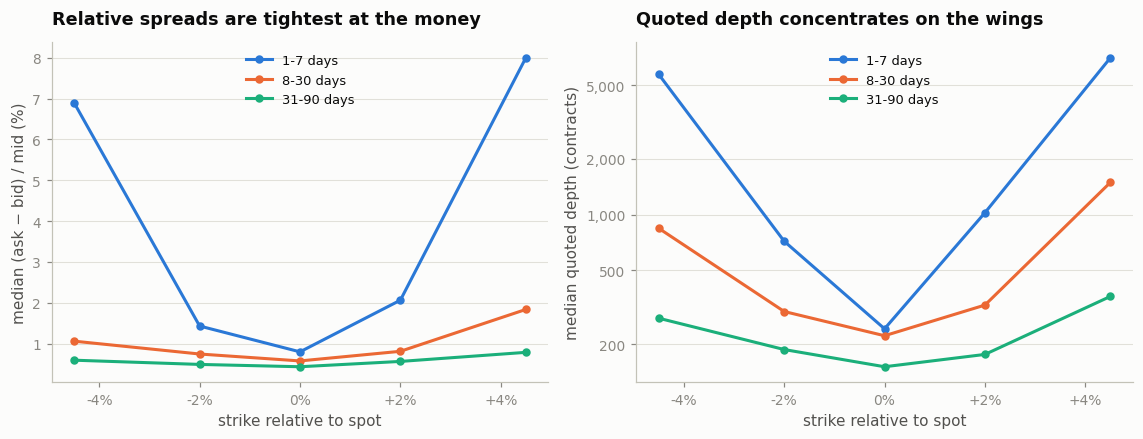

In [5]:
liq = opt[opt["DTE"] >= 1].copy()
liq["REL_SPREAD"] = np.where(liq["MONEYNESS"] >= 1,
                             (liq["C_ASK"] - liq["C_BID"]) / liq["C_MID"],
                             (liq["P_ASK"] - liq["P_BID"]) / liq["P_MID"])
liq["DEPTH"] = np.where(liq["MONEYNESS"] >= 1,
                        liq["C_BID_SIZE"] + liq["C_ASK_SIZE"],
                        liq["P_BID_SIZE"] + liq["P_ASK_SIZE"])
live = np.where(liq["MONEYNESS"] >= 1, liq["C_BID"] > 0, liq["P_BID"] > 0)
liq = liq[live]

dte_b = pd.cut(liq["DTE"], [0.5, 7, 30, 90], labels=["1-7 days", "8-30 days", "31-90 days"])
edges = [-0.06, -0.03, -0.01, 0.01, 0.03, 0.06]
mny_b = pd.cut(liq["MONEYNESS"] - 1, edges)
mids = [(a + b) / 2 for a, b in zip(edges[:-1], edges[1:])]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.1))
for color, b in zip(CAT, ["1-7 days", "8-30 days", "31-90 days"]):
    grp_b = liq[dte_b == b]
    spr = grp_b.groupby(mny_b, observed=False)["REL_SPREAD"].median() * 100
    dep = grp_b.groupby(mny_b, observed=False)["DEPTH"].median()
    ax1.plot(mids, spr.values, color=color, lw=2, marker="o", ms=4.5, label=b)
    ax2.plot(mids, dep.values, color=color, lw=2, marker="o", ms=4.5, label=b)

ax1.set_title("Relative spreads are tightest at the money")
ax1.set_ylabel("median (ask − bid) / mid (%)")
ax2.set_title("Quoted depth concentrates on the wings")
ax2.set_ylabel("median quoted depth (contracts)")
ax2.set_yscale("log")
ax2.set_yticks([200, 500, 1000, 2000, 5000])
ax2.set_yticklabels(["200", "500", "1,000", "2,000", "5,000"])
ax2.yaxis.set_minor_locator(plt.NullLocator())
for ax in (ax1, ax2):
    ax.set_xlabel("strike relative to spot")
    ax.set_xticks([-0.04, -0.02, 0, 0.02, 0.04])
    ax.set_xticklabels(["-4%", "-2%", "0%", "+2%", "+4%"])
    ax.legend(fontsize=8.5)
    tidy(ax)
fig.tight_layout(); plt.show()

## 5 · Implied volatility term structure

ATM IV is the average call and put IV at the strike nearest spot. Across 30 expiries observed on both Monday and Friday, 28 ended lower, with a median decline of about **1 volatility point**. The largest repricing occurred at the front end; part of its sawtooth is a day-count effect examined in section 6.


Mon->Fri ATM IV: lower at 28 of 30 common expiries; median decline 1.05 vol pts


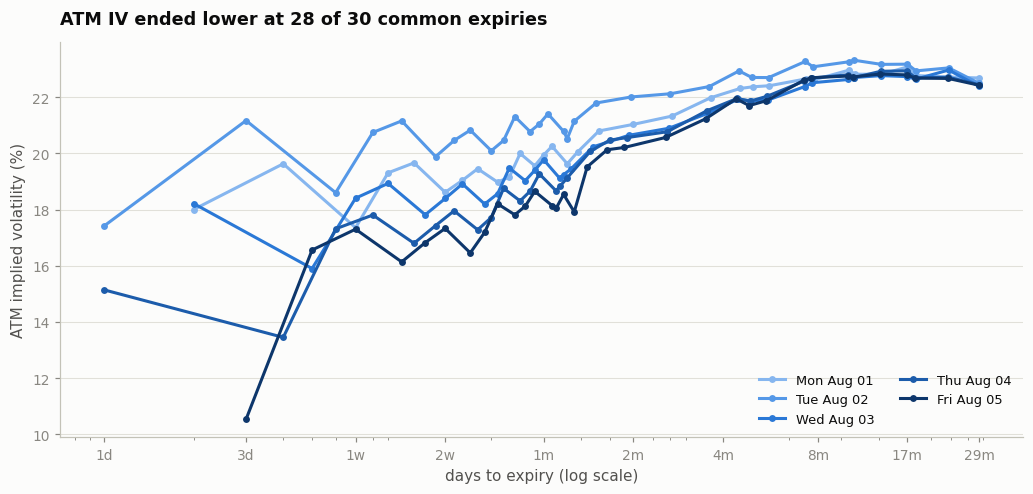

In [6]:
rows = []
for (d, e), g in opt[opt["DTE"] > 0].groupby(["QUOTE_DATE", "EXPIRE_DATE"]):
    g = g.dropna(subset=["C_IV", "P_IV"])
    if g.empty:
        continue
    atm = g.loc[g["STRIKE_DISTANCE"].idxmin()]
    rows.append({"day": d, "expiry": e, "dte": atm["DTE"],
                 "iv": (atm["C_IV"] + atm["P_IV"]) / 2 * 100})
ts = pd.DataFrame(rows)
term_week = ts.pivot(index="expiry", columns="day", values="iv").dropna()
first_day, last_day = term_week.columns.min(), term_week.columns.max()
n_lower = int((term_week[last_day] < term_week[first_day]).sum())
med_decline = (term_week[first_day] - term_week[last_day]).median()
print(f"Mon->Fri ATM IV: lower at {n_lower} of {len(term_week)} common expiries; "
      f"median decline {med_decline:.2f} vol pts")

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for color, (d, g) in zip(SEQ, ts.groupby("day")):
    g = g.sort_values("dte")
    ax.plot(g["dte"], g["iv"], color=color, lw=2, marker="o", ms=3.5,
            label=d.strftime("%a %b %d"))

ax.set_xscale("log")
ax.set_xticks([1, 3, 7, 14, 30, 60, 120, 250, 500, 870])
ax.set_xticklabels(["1d", "3d", "1w", "2w", "1m", "2m", "4m", "8m", "17m", "29m"])
ax.set_title(f"ATM IV ended lower at {n_lower} of {len(term_week)} common expiries")
ax.set_xlabel("days to expiry (log scale)")
ax.set_ylabel("ATM implied volatility (%)")
ax.legend(loc="lower right", fontsize=8.5, ncol=2)
tidy(ax)
fig.tight_layout(); plt.show()

## 6 · Trading-day and forward volatility

The file's `DTE` column counts calendar days (Friday's Aug-08 expiry shows 3.0), so IV is annualized over calendar time. Re-expressing total implied variance over business sessions provides an alternative convention for comparing expiries that span weekends:

- **Trading-day annualization** assumes variance accrues only during business sessions. It lifts Friday's Aug-08 mark from about 10.5% to about 15% and reduces most of the front-expiry sawtooth. Under this normalization, lower calendar-day IV for Monday and Wednesday expiries largely reflects weekend days in time to expiry.
- **Forward variance** compares adjacent expiry intervals using nearest-strike ATM midpoint IV. The approximate estimate for the final session of the week is **12.6%** annualized, below every interval in the following week, including **19.3%** for the two-session interval ending the next Wednesday.

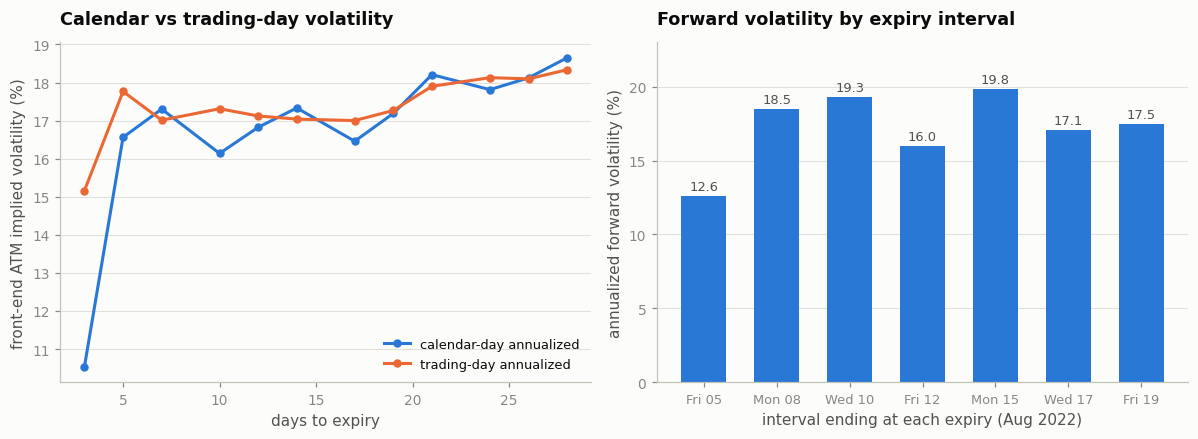

In [7]:
fri = opt[opt["QUOTE_DATE"] == "2022-08-05"].copy()

def atm_iv_row(g):
    g = g.dropna(subset=["C_IV", "P_IV"])
    if g.empty:
        return np.nan
    r = g.loc[g["STRIKE_DISTANCE"].idxmin()]
    return (r["C_IV"] + r["P_IV"]) / 2

# Friday front end: calendar vs trading-day annualization
front = []
for exp, g in fri[fri["DTE"].between(0.5, 30)].groupby("EXPIRE_DATE"):
    iv = atm_iv_row(g)
    bd = np.busday_count("2022-08-05", exp.strftime("%Y-%m-%d"))
    if np.isnan(iv) or bd < 1:
        continue
    dte = g["DTE"].iloc[0]
    front.append({"dte": dte, "cal": iv * 100,
                  "td": iv * np.sqrt((dte / 365) / (bd / 252)) * 100})
front = pd.DataFrame(front).sort_values("dte")

# per-session forward vol from Thursday's term structure
thu = opt[opt["QUOTE_DATE"] == "2022-08-04"]
tv = []
for exp, g in thu[thu["DTE"].between(0.5, 16)].groupby("EXPIRE_DATE"):
    iv = atm_iv_row(g)
    if np.isnan(iv):
        continue
    tv.append({"exp": exp, "bd": np.busday_count("2022-08-04", exp.strftime("%Y-%m-%d")),
               "var": iv ** 2 * g["DTE"].iloc[0] / 365})
segs, prev_bd, prev_var = [], 0, 0.0
for r in tv:
    incremental_var = r["var"] - prev_var
    assert incremental_var > 0, "adjacent expiries imply non-positive forward variance"
    fwd = np.sqrt(incremental_var / (r["bd"] - prev_bd) * 252) * 100
    segs.append({"label": r["exp"].strftime("%a %d"), "fwd": fwd})
    prev_bd, prev_var = r["bd"], r["var"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.1))
ax1.plot(front["dte"], front["cal"], color=BLUE, lw=2, marker="o", ms=4.5,
         label="calendar-day annualized")
ax1.plot(front["dte"], front["td"], color=ORANGE, lw=2, marker="o", ms=4.5,
         label="trading-day annualized")
ax1.set_title("Calendar vs trading-day volatility")
ax1.set_xlabel("days to expiry")
ax1.set_ylabel("front-end ATM implied volatility (%)")
ax1.legend(fontsize=8.5, loc="lower right")
tidy(ax1)

xs = np.arange(len(segs))
ax2.bar(xs, [s["fwd"] for s in segs], width=0.62, color=BLUE)
for i, s in enumerate(segs):
    ax2.annotate(f"{s['fwd']:.1f}", (i, s["fwd"]), textcoords="offset points",
                 xytext=(0, 4), ha="center", fontsize=8.5, color=SEC)
ax2.set_xticks(xs)
ax2.set_xticklabels([s["label"] for s in segs], fontsize=8.5)
ax2.set_title("Forward volatility by expiry interval")
ax2.set_xlabel("interval ending at each expiry (Aug 2022)")
ax2.set_ylabel("annualized forward volatility (%)")
ax2.set_ylim(0, 23)
tidy(ax2)
fig.tight_layout(); plt.show()

## 7 · Smile and skew

The smile uses the out-of-the-money side at each strike: puts below spot and calls above spot. Downside IV rises faster than upside IV at each plotted maturity, and the 25-delta put-minus-call risk reversal steepens with maturity, from about **+1 vol point** at one week to about **+9 vol points** at ten months (Friday values). Tracked day by day, front-end skew rose with Tuesday's selloff, then compressed through the rest of the week, while the long end barely changed.


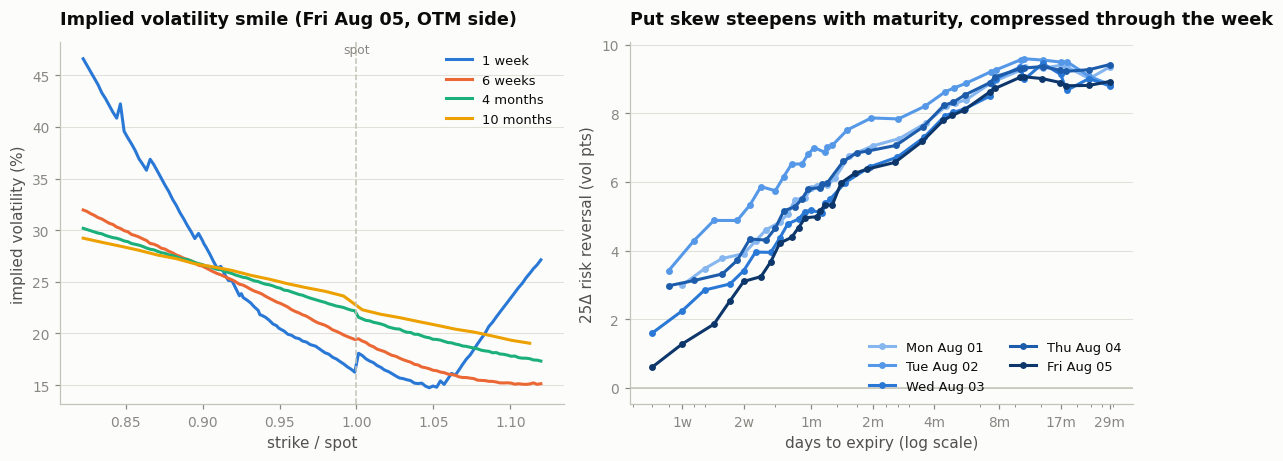

In [8]:
fri = opt[opt["QUOTE_DATE"] == "2022-08-05"].copy()
spot = fri["UNDERLYING_LAST"].iloc[0]
fri["OTM_IV"] = np.where(fri["MONEYNESS"] >= 1, fri["C_IV"], fri["P_IV"])
fri["OTM_BID"] = np.where(fri["MONEYNESS"] >= 1, fri["C_BID"], fri["P_BID"])

picks = [("2022-08-12", "1 week"), ("2022-09-16", "6 weeks"),
         ("2022-12-16", "4 months"), ("2023-06-16", "10 months")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.3))

for color, (exp, label) in zip(CAT, picks):
    g = fri[(fri["EXPIRE_DATE"] == exp) & fri["MONEYNESS"].between(0.82, 1.12)
            & (fri["OTM_BID"] > 0)].dropna(subset=["OTM_IV"]).sort_values("STRIKE")
    ax1.plot(g["MONEYNESS"], g["OTM_IV"] * 100, color=color, lw=2, label=label)
ax1.axvline(1, color=AXIS, lw=1, ls="--")
ax1.text(1.0, 0.97, "spot", transform=ax1.get_xaxis_transform(), ha="center",
         fontsize=8, color=MUT)
ax1.set_title("Implied volatility smile (Fri Aug 05, OTM side)")
ax1.set_xlabel("strike / spot")
ax1.set_ylabel("implied volatility (%)")
ax1.set_xticks([0.85, 0.90, 0.95, 1.00, 1.05, 1.10])
ax1.legend(loc="upper right", fontsize=8.5)
tidy(ax1)

rr = []
for (d, exp), g in opt[opt["DTE"] >= 5].groupby(["QUOTE_DATE", "EXPIRE_DATE"]):
    gc = g.dropna(subset=["C_IV"]).sort_values("C_DELTA")
    gp = g.dropna(subset=["P_IV"]).sort_values("P_DELTA")
    if len(gc) < 5 or len(gp) < 5:
        continue
    c25 = np.interp(0.25, gc["C_DELTA"], gc["C_IV"])
    p25 = np.interp(-0.25, gp["P_DELTA"], gp["P_IV"])
    rr.append({"day": d, "dte": g["DTE"].iloc[0], "rr": (p25 - c25) * 100})
rr = pd.DataFrame(rr)

for color, (d, g) in zip(SEQ, rr.groupby("day")):
    g = g.sort_values("dte")
    ax2.plot(g["dte"], g["rr"], color=color, lw=2, marker="o", ms=3.5,
             label=d.strftime("%a %b %d"))
ax2.legend(fontsize=8.5, loc="lower right", ncol=2)
ax2.set_xscale("log")
ax2.set_xticks([7, 14, 30, 60, 120, 250, 500, 870])
ax2.set_xticklabels(["1w", "2w", "1m", "2m", "4m", "8m", "17m", "29m"])
ax2.axhline(0, color=AXIS, lw=1)
ax2.set_title("Put skew steepens with maturity, compressed through the week")
ax2.set_xlabel("days to expiry (log scale)")
ax2.set_ylabel("25Δ risk reversal (vol pts)")
tidy(ax2)
fig.tight_layout(); plt.show()

## 8 · Greeks near the money

Friday's nearest live ATM calls show the trade-off between convexity and decay. Three-day gamma is about **11 times** the four-month value (**0.082 vs 0.007**), while absolute theta is about **2.5 times** as large (**0.222 vs 0.088**). Short-dated options react more sharply to spot moves but lose time value faster. Theta is not monotonic at the front: the three-day point spans a weekend and sits below the next two expiries.

Across a ±6% near-spot window, the same maturities show delta changing most sharply near expiry and gamma peaking at the money; the gamma peak sits on the strikes where volume concentrates in section 3. The focused window excludes isolated Greek irregularities farther from spot. Contracts with no live bid are excluded, and the per-strike series are median-filtered across three adjacent strikes to reduce point noise. These are row-level Greeks from the file; without open interest or signed positions, they do not measure aggregate exposure.


3-day ATM call: gamma 0.0823, |theta| 0.222
4-month ATM call: gamma 0.0073, |theta| 0.088


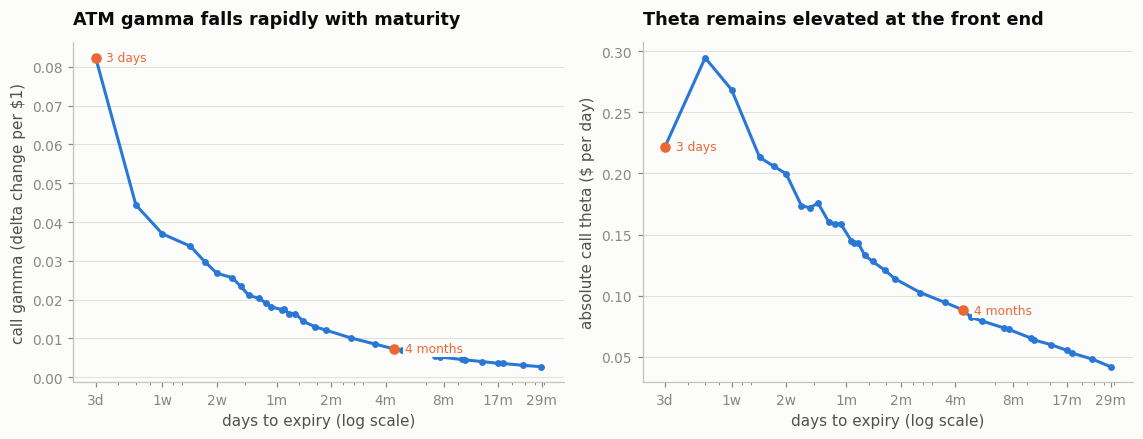

In [9]:
greek_rows = []
for expiry, g in fri[fri["DTE"] > 0].groupby("EXPIRE_DATE"):
    live = g[(g["C_BID"] > 0) & g["C_DELTA"].between(0, 1) & (g["C_GAMMA"] >= 0)]
    live = live.dropna(subset=["C_GAMMA", "C_THETA"])
    if live.empty:
        continue
    atm = live.loc[live["STRIKE_DISTANCE"].idxmin()]
    greek_rows.append({"expiry": expiry, "dte": atm["DTE"],
                       "gamma": atm["C_GAMMA"], "abs_theta": abs(atm["C_THETA"])})

greeks = pd.DataFrame(greek_rows).sort_values("dte")
focus = greeks.loc[[greeks["dte"].idxmin(), (greeks["dte"] - 133).abs().idxmin()]]
for tag, (_, r) in zip(["3-day", "4-month"], focus.iterrows()):
    print(f"{tag} ATM call: gamma {r['gamma']:.4f}, |theta| {r['abs_theta']:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.1))
ax1.plot(greeks["dte"], greeks["gamma"], color=BLUE, lw=2, marker="o", ms=3.5)
ax1.scatter(focus["dte"], focus["gamma"], color=ORANGE, s=35, zorder=3)
for label, (_, row) in zip(["3 days", "4 months"], focus.iterrows()):
    ax1.annotate(label, (row["dte"], row["gamma"]), xytext=(7, 0), va="center",
                 textcoords="offset points", fontsize=8, color=ORANGE,
                 bbox={"facecolor": SURF, "edgecolor": "none", "pad": 1})
ax1.set_title("ATM gamma falls rapidly with maturity")
ax1.set_ylabel("call gamma (delta change per $1)")

ax2.plot(greeks["dte"], greeks["abs_theta"], color=BLUE, lw=2, marker="o", ms=3.5)
ax2.scatter(focus["dte"], focus["abs_theta"], color=ORANGE, s=35, zorder=3)
for label, (_, row) in zip(["3 days", "4 months"], focus.iterrows()):
    ax2.annotate(label, (row["dte"], row["abs_theta"]), xytext=(7, 0), va="center",
                 textcoords="offset points", fontsize=8, color=ORANGE,
                 bbox={"facecolor": SURF, "edgecolor": "none", "pad": 1})
ax2.set_title("Theta remains elevated at the front end")
ax2.set_ylabel("absolute call theta ($ per day)")

ticks = [3, 7, 14, 30, 60, 120, 250, 500, 870]
for ax in (ax1, ax2):
    ax.set_xscale("log")
    ax.set_xticks(ticks)
    ax.set_xticklabels(["3d", "1w", "2w", "1m", "2m", "4m", "8m", "17m", "29m"])
    ax.set_xlabel("days to expiry (log scale)")
    tidy(ax)
fig.tight_layout(); plt.show()

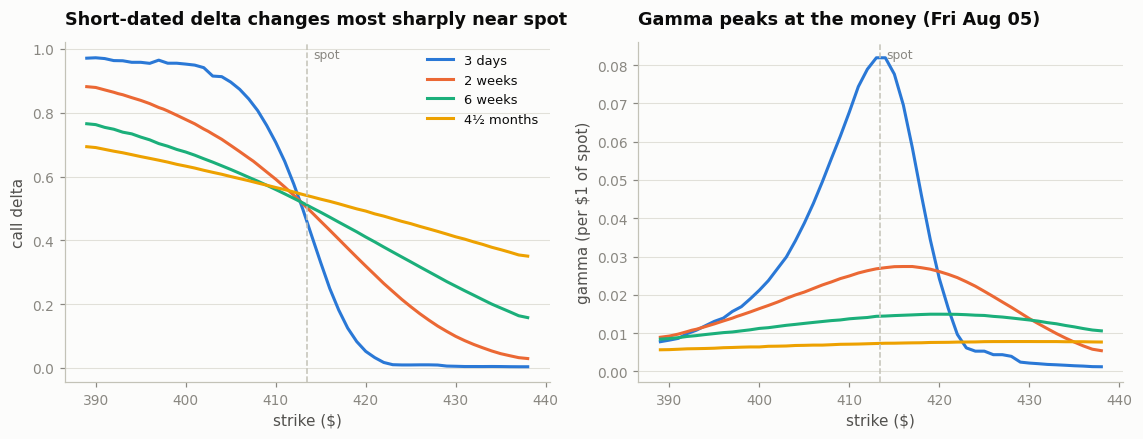

In [10]:
gpicks = [("3 days", "2022-08-08"), ("2 weeks", "2022-08-19"),
          ("6 weeks", "2022-09-16"), ("4½ months", "2022-12-16")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.1))
for color, (label, exp) in zip(CAT, gpicks):
    g = fri[fri["EXPIRE_DATE"] == exp].sort_values("STRIKE")
    g = g[g["MONEYNESS"].between(0.94, 1.06) & (g["C_BID"] > 0) & (g["C_GAMMA"] >= 0)]
    delta = g["C_DELTA"].rolling(3, center=True, min_periods=1).median()
    gamma = g["C_GAMMA"].rolling(3, center=True, min_periods=1).median()
    ax1.plot(g["STRIKE"], delta, color=color, lw=2, label=label)
    ax2.plot(g["STRIKE"], gamma, color=color, lw=2, label=label)

for ax, ttl, ylab in [(ax1, "Short-dated delta changes most sharply near spot", "call delta"),
                      (ax2, "Gamma peaks at the money (Fri Aug 05)", "gamma (per $1 of spot)")]:
    ax.axvline(spot, color=AXIS, lw=1, ls="--")
    ax.annotate("spot", (spot, ax.get_ylim()[1]), textcoords="offset points",
                xytext=(4, -10), fontsize=8, color=MUT)
    ax.set_title(ttl)
    ax.set_xlabel("strike ($)")
    ax.set_ylabel(ylab)
    tidy(ax)
ax1.legend(fontsize=8.5)
fig.tight_layout(); plt.show()

## 9 · Implied forwards from put-call parity

The file has no forward prices or carry inputs, but near-ATM call-put differences can recover an approximate forward under `C - P = D(T) * (F - K)`. For each expiry, a regression of `C - P` on strike `K` gives:

- **slope** = `-D(T)`, an implied discount term
- **intercept / -slope** = `F`, the implied forward price

The recovered forward curve ends near **$431** for Dec 2024, or about **+1.8%/yr** net carry over spot. It also drops between the Sep-12 and Sep-16 expiries, showing a discrete carry adjustment in the option prices.

*Caveat*: exercise conventions and carry components are not identified in the file. The parity slope is therefore not reported as an interest-rate estimate; the forward and carry figures are approximate, and the displayed table excludes the shortest maturities.


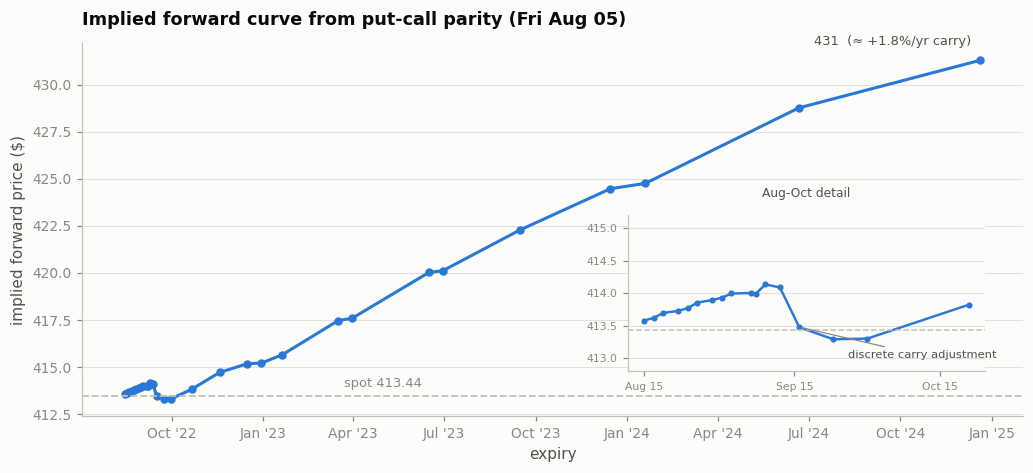

,expiry,dte,forward,carry_pct_yr
0,2022-10-21,77.00,413.82,0.44
1,2022-11-18,105.04,414.71,1.07
2,2022-12-16,133.04,415.18,1.16
3,2022-12-30,147.04,415.21,1.06
4,2023-01-20,168.04,415.66,1.16
5,2023-03-17,224.00,417.47,1.58
6,2023-03-31,238.00,417.60,1.53
7,2023-06-16,315.00,420.02,1.83
8,2023-06-30,329.00,420.12,1.78
9,2023-09-15,406.00,422.27,1.90


In [11]:
fw = []
for exp, g in fri.groupby("EXPIRE_DATE"):
    T = g["T_YEARS"].iloc[0]
    if g["DTE"].iloc[0] < 8:
        continue
    sel = g[(g["STRIKE_DISTANCE_PCT"] < 0.05) & (g["C_BID"] > 0) & (g["P_BID"] > 0)]
    if len(sel) < 6:
        continue
    slope, intercept = np.polyfit(sel["STRIKE"], sel["C_MID"] - sel["P_MID"], 1)
    F = intercept / -slope
    fw.append({"expiry": exp, "dte": g["DTE"].iloc[0], "forward": F,
               "carry_pct_yr": np.log(F / spot) / T * 100})
fw = pd.DataFrame(fw).sort_values("dte")

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(fw["expiry"], fw["forward"], color=BLUE, lw=2, marker="o", ms=4.5)
ax.axhline(spot, color=AXIS, lw=1.2, ls="--")
ax.annotate(f"spot {spot:.2f}", (pd.Timestamp("2023-05-01"), spot), textcoords="offset points",
            xytext=(0, 6), ha="center", fontsize=8.5, color=MUT)
last = fw.iloc[-1]
ax.annotate(f"{last['forward']:.0f}  (≈ +{last['carry_pct_yr']:.1f}%/yr carry)",
            (last["expiry"], last["forward"]), textcoords="offset points",
            xytext=(-6, 10), ha="right", fontsize=8.5, color=SEC)
ax.set_title("Implied forward curve from put-call parity (Fri Aug 05)")
ax.set_xlabel("expiry")
ax.set_ylabel("implied forward price ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
tidy(ax)

axi = ax.inset_axes([0.58, 0.12, 0.38, 0.42])
sub_fw = fw[fw["expiry"] <= "2022-10-31"]
axi.plot(sub_fw["expiry"], sub_fw["forward"], color=BLUE, lw=1.6, marker="o", ms=3)
axi.axhline(spot, color=AXIS, lw=1, ls="--")
axi.annotate("discrete carry adjustment", xy=(pd.Timestamp("2022-09-16"), 413.48),
             xytext=(pd.Timestamp("2022-09-26"), 413.0), fontsize=7.5, color=SEC,
             arrowprops=dict(arrowstyle="-", color=MUT, lw=0.8))
axi.set_title("Aug-Oct detail", fontsize=8, color=SEC, fontweight="normal", loc="center")
axi.set_xticks([pd.Timestamp("2022-08-15"), pd.Timestamp("2022-09-15"), pd.Timestamp("2022-10-15")])
axi.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axi.tick_params(labelsize=7)
axi.set_ylim(412.8, 415.2)
tidy(axi)
fig.tight_layout(); plt.show()

show = fw[fw["dte"] >= 60].copy()
show["expiry"] = show["expiry"].dt.date
show.round(2).reset_index(drop=True)

## 10 · Straddle break-evens and outcomes

An ATM straddle's exact terminal break-evens are `K ± premium`. On Thursday Aug 4, the 414-strike Friday straddle had a **$3.445** mid premium, giving break-evens of **$410.56 (-0.88%)** and **$417.45 (+0.78%)** relative to Thursday's close. SPY closed Friday at **$413.44 (-0.18%)**; the **$0.56** intrinsic payoff recovered **16%** of the premium. Tuesday-to-Wednesday was the only interval whose expiry close finished outside the corresponding break-even range.

Quotes use mid prices and outcomes use closing prices. Intraday paths and executable transaction costs are not observable.


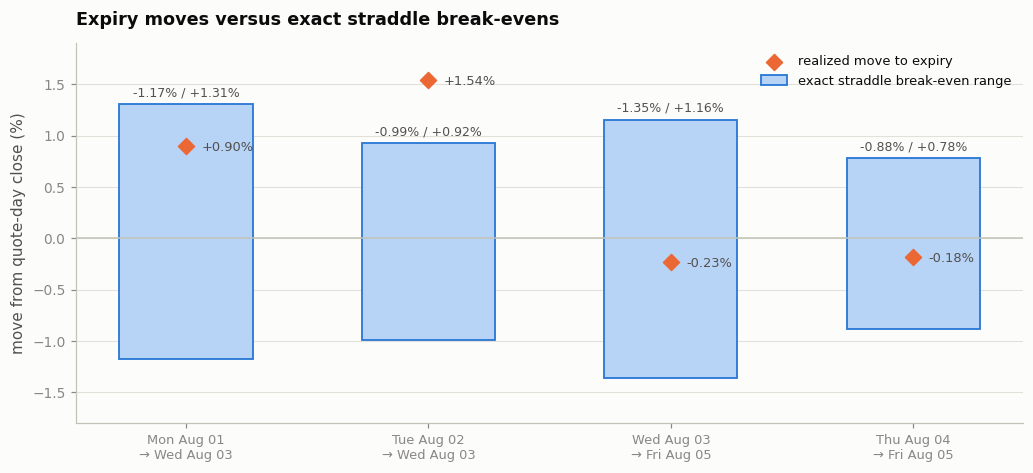

,quote day,expiry,K,premium_$,lower_be_pct,upper_be_pct,realized_move_pct,premium_recovered_pct
0,Mon Aug 01,Wed Aug 03,411.0,5.100,-1.17,1.31,0.90,66.86
1,Tue Aug 02,Wed Aug 03,408.0,3.905,-0.99,0.92,1.54,164.15
2,Wed Aug 03,Fri Aug 05,414.0,5.205,-1.35,1.16,-0.23,10.76
3,Thu Aug 04,Fri Aug 05,414.0,3.445,-0.88,0.78,-0.18,16.26
4,Fri Aug 05,Mon Aug 08,413.0,3.535,-0.96,0.75,NaN,NaN


In [12]:
snap = opt.groupby("QUOTE_DATE")["UNDERLYING_LAST"].first()
ev = []
for d, g in opt[opt["DTE"] > 0].groupby("QUOTE_DATE"):
    exp = g["EXPIRE_DATE"].min()                       # nearest live expiry
    gg = g[g["EXPIRE_DATE"] == exp]
    atm = gg.loc[gg["STRIKE_DISTANCE"].idxmin()]
    S, K = gg["UNDERLYING_LAST"].iloc[0], atm["STRIKE"]
    premium = atm["C_MID"] + atm["P_MID"]
    lower_be = ((K - premium) / S - 1) * 100
    upper_be = ((K + premium) / S - 1) * 100
    realized = (snap[exp] / S - 1) * 100 if exp in snap.index else np.nan
    recovered = abs(snap[exp] - K) / premium * 100 if exp in snap.index else np.nan
    ev.append({"quote day": d.strftime("%a %b %d"), "expiry": exp.strftime("%a %b %d"),
               "K": K, "premium_$": premium, "lower_be_pct": lower_be,
               "upper_be_pct": upper_be, "realized_move_pct": realized,
               "premium_recovered_pct": recovered})
ev = pd.DataFrame(ev)

plot = ev.dropna(subset=["realized_move_pct"])
x = np.arange(len(plot))
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(x, plot["upper_be_pct"] - plot["lower_be_pct"], bottom=plot["lower_be_pct"],
       width=0.55, color=LIGHT_BLUE, edgecolor=BLUE, linewidth=1.2,
       label="exact straddle break-even range")
ax.scatter(x, plot["realized_move_pct"], color=ORANGE, marker="D", s=55, zorder=3,
           label="realized move to expiry")
for i, row in enumerate(plot.itertuples()):
    ax.annotate(f"{row.lower_be_pct:+.2f}% / {row.upper_be_pct:+.2f}%",
                (i, row.upper_be_pct), textcoords="offset points", xytext=(0, 5),
                ha="center", fontsize=8.2, color=SEC)
    ax.annotate(f"{row.realized_move_pct:+.2f}%", (i, row.realized_move_pct),
                textcoords="offset points", xytext=(10, -3), fontsize=8.5, color=SEC)
ax.axhline(0, color=AXIS, lw=1)
ax.set_ylim(-1.8, 1.9)
ax.set_xticks(x)
ax.set_xticklabels([f"{a}\n→ {b}" for a, b in zip(plot["quote day"], plot["expiry"])],
                   fontsize=8.5)
ax.set_title("Expiry moves versus exact straddle break-evens")
ax.set_ylabel("move from quote-day close (%)")
ax.legend(fontsize=8.5, loc="upper right")
tidy(ax)
fig.tight_layout(); plt.show()

ev.round({"K": 0, "premium_$": 3, "lower_be_pct": 2, "upper_be_pct": 2,
          "realized_move_pct": 2, "premium_recovered_pct": 2})


## 11 · Conclusions

**What happened.** Trading concentrated in short-dated options all week, with put volume above call volume each day. The index finished nearly unchanged: Friday's close was down only **0.18%** from Thursday, well inside the Thursday 414-strike straddle's **-0.88% / +0.78%** break-even range, leaving an expiration payoff equal to **16%** of its premium. By Friday close, ATM IV was lower than Monday at **28 of 30** comparable expiries, led by the front end.

**Why each finding matters:**

- **Cleaning determines what the data can say.** The missingness is structured: blank IVs occur on deep-ITM rows, while blank daily volume is treated as zero only for aggregation. Of 1,782 IVs outside the operational 1%-200% screen, just four enter the live OTM, positive-DTE sample used in the surface analysis. This prevents extreme vendor fits from distorting the reported smile and skew.
- **Activity and usable quotes concentrate near spot and expiry.** Contracts expiring within one day account for **41%** of volume on about **3%** of listed rows. Near-ATM spreads are under **1%** of mid, while short-dated wings are several percentage points wide despite greater displayed size. Volume is unsigned, so the evidence supports concentrated activity and cheaper execution near spot, not a claim about trader direction.
- **Day count changes the apparent front-end signal.** Friday's Aug-08 ATM IV is **10.5%** on the calendar-day basis implied by `DTE` and about **15%** under a business-session allocation. Part of the apparent weekend cheapness is mechanical rather than a change in expected variance.
- **Adjacent expiries price individual intervals.** Using nearest-strike ATM midpoint IV, Thursday's curve gives approximate forward-volatility estimates of **12.6%** annualized for the final session of the week, below every later interval in the two-week strip, which reach **19.8%**.
- **Greeks show why short-dated options are demanding to hold.** At Friday's nearest live ATM strike, three-day call gamma is about **11 times** its four-month value, while absolute theta is about **2.5 times** as large. Within ±6% of spot, the shortest maturity has the sharpest delta transition and highest ATM gamma. Without open interest and signed positions, these row-level Greeks do not reveal aggregate exposure.
- **The volatility surface separates transient and persistent downside pricing.** Front-end skew rose with Tuesday's selloff and compressed later in the week, while ten-month put-minus-call skew remained near **+9 vol points**. The data support fading short-horizon uncertainty alongside persistent long-dated downside skew, without identifying positions or intent.
- **Parity extracts an approximate carry signal from the chain.** Near-ATM put-call differences imply a forward near **$431** for Dec 2024, about **+1.8%/yr** net carry, with a discrete adjustment between the Sep-12 and Sep-16 expiries. Because exercise conventions and carry components are not identified in the file, these are approximate forwards rather than separately identified inputs.
- **Friday's move did not clear the price already embedded in options.** Of the four next-expiry intervals with an observable expiry close in this file, three finished inside their exact straddle break-evens; Tuesday-to-Wednesday was the exception. Four observations are insufficient to judge calibration or strategy profitability; three expiration payoffs recovered less than their quoted midpoint premiums.

**Extensions**: repeat the parity estimate across quote dates, fit an arbitrage-aware volatility surface, and test sensitivity to strike-selection windows.